## Imports

In [ ]:
# requires to install eofs and gpytorch
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
#import gpytorch
import os
import glob
#from eofs.xarray import Eof

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from typing import Dict, Optional, List, Callable, Tuple, Union

#import wandb
#from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/home/user')  # must be first
sys.path.insert(1, '/home/user/equivariant-posteriors/experiments/climate/persisted_configs')


from experiments.climate.evaluation.metrics import LLweighted_RMSE_Climax
from experiments.climate.data.climateset_data_no_hp import ClimatesetData, ClimatesetConfig
from experiments.climate.data.climateset_data_no_hp import load_training_stats_from_config
import LPS as ps
import numpy as np
import torch

/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[Compute environment] paths: 
[Paths] checkpoints: /proj/heal_pangu/eqp_climate/checkpoints (/proj/heal_pangu/eqp_climate/checkpoints)
[Paths] locks: locks (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/locks)
[Paths] distributed_requests: distributed_requests (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/distributed_requests)
[Paths] artifacts: /proj/heal_pangu/eqp_climate/artifacts (/proj/heal_pangu/eqp_climate/artifacts)
[Paths] datasets: /proj/heal_pangu/users/x_tagty/climateset (/proj/heal_pangu/users/x_tagty/climateset)
[Compute environment] envs: None


## Load data v1

In [26]:
train_config = ClimatesetConfig(
    climate_model="AWI-CM-1-1-MR",
    ensemble="r1i1p1f1", 
    output_vars=["tas", "pr"],
    scenarios=["ssp585", "ssp126", "ssp370"],
    split="train",        # use all samples, not train/val split
    normalized=True,   # raw values for statistical analysis
)

train_ds = ClimatesetData(train_config)

# Access raw arrays directly — already in memory, no batching needed
X_train = train_ds.input_data # [train_ds.indices]   # shape: (3096, seq_len, n_input_vars, lon, lat)
X_train.shape
Y_train = train_ds.output_data #[train_ds.indices]  # shape: (3096, seq_len, n_output_vars, lon, lat)


Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp126_ssp370_ssp585_2015-2100_nohistoric_all-fires
  Loaded INPUT from cache: shape=(3096, 4, 96, 144)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_AWI-CM-1-1-MR_r1i1p1f1_grid_tas_pr_ssp126_ssp370_ssp585_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(3096, 2, 96, 144)
Split: train
  Total timesteps:    3096
  Sequence length:    12
  Complete sequences: 258
  Using 233 sequences (233 start indices)

Computing normalization stats from TRAIN split only...
  INPUT normalization stats (from 2796 train timesteps):
    BC: mean=3.137485e-13, std=1.927971e-12
    CH4: mean=2.023336e-11, std=1.234526e-10
    SO2: mean=2.932941e-12, std=3.357126e-11
    CO2: mean=2.764126e-09, std=2.766130e-08
  OUTPUT normalization stats (from 2796 train timesteps):
    tas: mean=2.803220e+02, std=2.102236e+01
    pr: mean=2.848664e-05, std=3.5057

In [5]:
stats = train_ds.get_normalization_stats()

in_mean = stats["input_stats"]["mean"]   # (1, C_in, 1, 1)
in_std  = stats["input_stats"]["std"]
#print(in_mean, in_std)
out_mean = stats["output_stats"]["mean"]  # (1, C_out, 1, 1)
out_std  = stats["output_stats"]["std"]
#print(out_mean, out_std)

X_train_raw = train_ds.input_data #[train_ds.indices]    # raw
Y_train_raw = train_ds.output_data #[train_ds.indices]

X_train = (X_train_raw - in_mean)  / in_std
Y_train = (Y_train_raw - out_mean) / out_std

X_train.shape

(3096, 4, 96, 144)

In [6]:
test_config = ClimatesetConfig(
    climate_model="AWI-CM-1-1-MR",
    ensemble="r1i1p1f1", 
    output_vars=["tas", "pr"],
    scenarios=["ssp245"],
    split="test",        # use all samples, not train/val split
    normalized=True,   # raw values for statistical analysis
)

test_ds = ClimatesetData(test_config)

# Access raw arrays directly — already in memory, no batching needed
X_test_raw = test_ds.input_data #[test_ds.indices]   # shape: (3096, seq_len, n_input_vars, lon, lat)
Y_test_raw = test_ds.output_data #[test_ds.indices]  # shape: (3096, seq_len, n_output_vars, lon, lat)

X_test = (X_test_raw - in_mean)  / in_std
Y_test = (Y_test_raw - out_mean) / out_std

Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp245_2015-2100_nohistoric_all-fires
  Loaded INPUT from cache: shape=(1032, 4, 96, 144)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_AWI-CM-1-1-MR_r1i1p1f1_grid_tas_pr_ssp245_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(1032, 2, 96, 144)
Using 86 start indices for split='test' (seq_len=12)
  split='test': stats must be provided explicitly.
  Call set_normalization_stats() before using this dataset.


In [5]:
Y_test.mean()

np.float64(-0.007058575230373621)

## Load data v2

In [3]:
import copy
from experiments.climate.data.climateset_data_no_hp import load_training_stats_from_config
from experiments.climate.evaluation.metrics import rmse_climate_nohp
from experiments.climate.persisted_configs.final_climateset_baseline_runs.train_climax_nohp_multiseed_latfix import create_config

train_run = create_config(ensemble_id=0, epoch=50)

# Exact same test config as evaluate_climate
train_data_config = train_run.train_config.train_data_config
test_data_config = copy.deepcopy(train_data_config)
train_ds = ClimatesetData(train_data_config)

stats = train_ds.get_normalization_stats()
in_mean = stats["input_stats"]["mean"]
in_std  = stats["input_stats"]["std"]
out_mean = stats["output_stats"]["mean"]
out_std  = stats["output_stats"]["std"]

X_train_raw = train_ds.input_data #[train_ds.indices]    # raw
Y_train_raw = train_ds.output_data #[train_ds.indices]
X_train = (X_train_raw - in_mean)  / in_std
Y_train = (Y_train_raw - out_mean) / out_std

test_data_config.scenarios = ["ssp245"]
test_data_config.split = "test"
test_ds = ClimatesetData(test_data_config)
stats = load_training_stats_from_config(train_run.train_config.train_data_config)
test_ds.set_normalization_stats(**stats)

X_test_raw = test_ds.input_data #[test_ds.indices]   # shape: (3096, seq_len, n_input_vars, lon, lat)
Y_test_raw = test_ds.output_data #[test_ds.indices]  # shape: (3096, seq_len, n_output_vars, lon, lat)

X_test = (X_test_raw - in_mean)  / in_std
Y_test = (Y_test_raw - out_mean) / out_std

#print(Y_test)
#test_dl = torch.utils.data.DataLoader(test_ds, batch_size=4, shuffle=False)
#results = rmse_climate_nohp(model_e30, test_dl, device, output_stats=stats["output_stats"])
#print(results["rmse_per_channel"])

/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


AWI-CM-1-1-MR r1i1p1f1
Using 16 workers [SLURM_CPUS_ON_NODE]
Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp126_ssp370_ssp585_2015-2100_nohistoric_anthro-fires
  Loaded INPUT from cache: shape=(3096, 4, 96, 144)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_AWI-CM-1-1-MR_r1i1p1f1_grid_tas_pr_ssp126_ssp370_ssp585_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(3096, 2, 96, 144)
Split: train
  Total timesteps:    3096
  Sequence length:    12
  Complete sequences: 258
  Using 233 sequences (233 start indices)

Computing normalization stats from TRAIN split only...
  INPUT normalization stats (from 2796 train timesteps):
    BC: mean=2.752777e-13, std=1.764997e-12
    CH4: mean=1.947813e-11, std=1.189614e-10
    SO2: mean=2.870719e-12, std=3.321957e-11
    CO2: mean=2.655968e-09, std=2.675241e-08
  OUTPUT normalization stats (from 2796 train timesteps):
    tas: mean=2.80

In [20]:
stats_from_obj  = train_ds.get_normalization_stats()
stats_from_disk = load_training_stats_from_config(train_run.train_config.train_data_config)

print(stats_from_obj["output_stats"]["mean"], stats_from_disk["output_stats"]["mean"])
print(stats_from_obj["output_stats"]["std"],  stats_from_disk["output_stats"]["std"])


Loaded input stats from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp126_ssp370_ssp585_2015-2100_nohistoric_anthro-fires/train_stats_seed1_valfrac0.1.npy
Loaded output stats from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_AWI-CM-1-1-MR_r1i1p1f1_grid_tas_pr_ssp126_ssp370_ssp585_2015-2100_nohistoric_250_km/train_stats_seed1_valfrac0.1.npy
[[[[2.80321964e+02]]

  [[2.84866444e-05]]]] [[[[2.80266383e+02]]

  [[2.84615212e-05]]]]
[[[[2.10223610e+01]]

  [[3.50573132e-05]]]] [[[[2.10359748e+01]]

  [[3.50340435e-05]]]]


## LPS - Only CO2 as in paper
#### Train

In [ ]:
n_train, _, lon, lat = Y_train.shape
n_test,  _, _, _   = Y_test.shape

lats_rad = np.deg2rad(np.linspace(-90, 90, lat))   # (144,)
lat_weights = np.cos(lats_rad)                      # (144,)
lat_weights /= lat_weights.sum()                    # normalize → sum to 1
def area_mean(arr):
    return (arr * lat_weights).sum(axis=-1).mean(axis=-1)

Y_global_test, (1032,)
Y_global_test, (1032,)


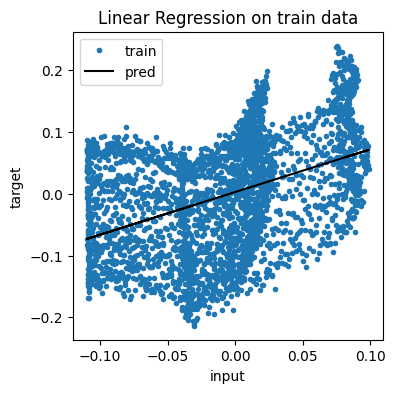

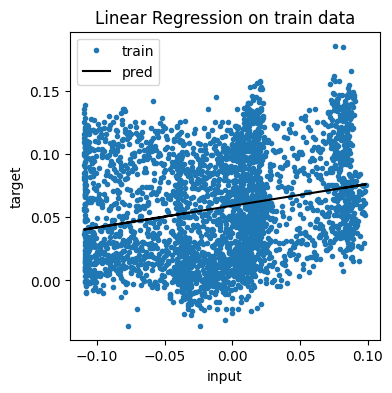

In [11]:
co2_idx = 3
var_config = {"tas": 0, "pr": 1}

# --- Shared input ---
# X_global_train1 = X_train[:, co2_idx, :, :].mean(axis=(-1, -2)).reshape(-1)
# X_global_test1  = X_test[:,  co2_idx, :, :].mean(axis=(-1, -2)).reshape(-1)
X_global_train = area_mean(X_train[:, co2_idx, :, :])
X_global_test  = area_mean(X_test[:,  co2_idx, :, :])

# --- Fit and store everything per variable ---
results = {}
for name, var_idx in var_config.items():
    # Y_global_train1 = Y_train[:, var_idx, :, :].mean(axis=(-1, -2)).reshape(-1)
    # Y_global_test1 = Y_test[:, var_idx, :, :].mean(axis=(-1, -2)).reshape(-1)
    Y_global_train = area_mean(Y_train[:, var_idx, :, :])  # (n_train,)
    Y_global_test  = area_mean(Y_test[:,  var_idx, :, :])  # (n_test,)
    
    print(f"Y_global_test, {Y_global_test.shape}")
    Y_local_train  = Y_train[:, var_idx, :, :].reshape(n_train, lon, lat)
    Y_local_test   = Y_test[:,  var_idx, :, :].reshape(n_test,  lon, lat)
    
    model_lr = ps.fit_linear_regression_global_global(
        input_array=X_global_train,
        target_array=Y_global_train,
        plot=True
    )
    # model_lr = ps.fit_linear_regression_global_global(
    #     input_array=X_global_train1,
    #     target_array=Y_global_train1,
    #     plot=True
    # )
    model_ps = ps.PatternScaling(deg=1)
    model_ps.train_multivariate(X_global_train, Y_local_train)

    results[name] = {
        "lr": model_lr,
        "ps": model_ps,
        "Y_global_test": Y_global_test,
        "Y_local_test": Y_local_test,
    }
    #print(results)

#### Evaluate

(1032, 96, 144)
got_to_plotting
tas — shape: (1032, 96, 144), LL-RMSE: 0.3170
(1032, 96, 144)
got_to_plotting
pr — shape: (1032, 96, 144), LL-RMSE: 0.7326


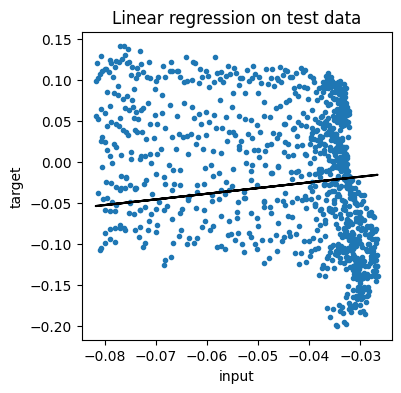

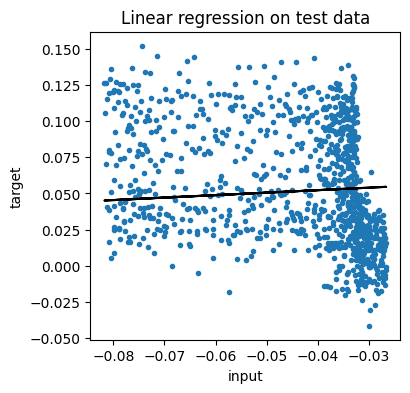

In [12]:
# --- Predict and evaluate ---
for name, r in results.items():
    print(r["Y_local_test"].shape)
    preds_global = ps.predict_linear_regression_global_global(
        r["lr"], input_array=X_global_test, target_array=r["Y_global_test"],
        plot=True,
    )
    preds_local = r["ps"].predict(preds_global.flatten())

    
    grid_point_pred = preds_local[:,48,72]
    grid_point_true = r["Y_local_test"][:,48,72]
    # fig, axs = plt.subplots(1,1, figsize =(4,4))
    # axs.plot(preds_global.flatten(), grid_point_true, '.', label='true')
    # axs.plot(preds_global.flatten(), grid_point_pred, color='black', label='pred')
    # axs.set_xlabel("input")
    # axs.set_ylabel("target")
    # axs.set_title("Linear Regression on train data")
    # axs.legend()

    rmse = LLweighted_RMSE_Climax(preds_local, r["Y_local_test"])
    
    results[name]["preds_local"] = preds_local  # store for later use too

    print(f"{name} — shape: {preds_local.shape}, LL-RMSE: {rmse:.4f}")

### Multivariate

In [13]:
var_config = {"tas": 0, "pr": 1}

# --- Shared input: all forcing channels, spatially averaged ---
# X_global_train = X_train.mean(axis=(-1, -2)).reshape(-1, X_train.shape[1])  # (n_time, 4)
# X_global_test  = X_test.mean(axis=(-1, -2)).reshape(-1, X_test.shape[1])    # (n_time, 4)
X_global_train = area_mean(X_train[:, co2_idx, :, :])
X_global_test  = area_mean(X_test[:,  co2_idx, :, :])

n_train, _, lon, lat = Y_train.shape
n_test,  _, _, _   = Y_test.shape

# --- Fit and store everything per variable ---
results = {}
for name, var_idx in var_config.items():
    #Y_global_train = Y_train[:, var_idx, :, :].mean(axis=(-1, -2)).reshape(-1)
    Y_global_train = area_mean(Y_train[:, var_idx, :, :])  # (n_train,)
    Y_global_test  = area_mean(Y_test[:,  var_idx, :, :])  # (n_test,)
    Y_local_train  = Y_train[:, var_idx, :, :].reshape(n_train, lon, lat)
    Y_local_test   = Y_test[:,  var_idx, :, :].reshape(n_test,  lon, lat)

    model_lr = ps.fit_linear_regression_global_global(
        input_array=X_global_train,   # (n_time, 4)
        target_array=Y_global_train,  # (n_time,)
    )
    model_ps = ps.PatternScaling(deg=1)
    model_ps.train_multivariate(in_global=X_global_train, out_local=Y_local_train)

    results[name] = {
        "lr":          model_lr,
        "ps":          model_ps,
        "Y_local_test": Y_local_test,
    }

# --- Predict and evaluate ---
for name, r in results.items():
    preds_global = ps.predict_linear_regression_global_global(
        r["lr"], input_array=X_global_test
    )
    preds_local = r["ps"].predict_multivariate(X_global_test)  # (n_time, lon, lat)
    rmse = LLweighted_RMSE_Climax(preds_local, r["Y_local_test"])

    results[name]["preds_local"] = preds_local

    print(f"{name} — shape: {preds_local.shape}, LL-RMSE: {rmse:.4f}")

tas — shape: (1032, 96, 144), LL-RMSE: 0.3178
pr — shape: (1032, 96, 144), LL-RMSE: 0.7311


## Load ClimaX model checkpoint

In [13]:
import importlib
import lib.compute_env
import torch
import lib.data_factory as data_factory
import lib.model_factory as model_factory
from experiments.climate.data.climateset_data_no_hp import ClimatesetConfig
from experiments.climate.data.climateset_data_no_hp import ClimatesetData
from experiments.climate.data.climateset_data_no_hp import get_fire_type
from experiments.climate.adapted_climateset_baselines.climax.climax_module import (
    ClimaXConfig,
    ClimaX,
)
lib.compute_env._current_env = None  # reset cached env
importlib.reload(lib.compute_env)

from experiments.climate.persisted_configs.final_climateset_baseline_runs.train_climax_nohp_multiseed_latfix import create_config
from lib.serialization import DeserializeConfig, deserialize_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(ensemble_id, checkpoint_epoch=50, load_epoch=None):
    train_run = create_config(ensemble_id=ensemble_id, epoch=checkpoint_epoch)
    if load_epoch is not None:
        train_run.epochs = load_epoch  # point to model_epoch_0030 instead of model
    d = deserialize_model(
        DeserializeConfig(train_run=train_run, device_id=device),
        latest_ok=(load_epoch is None),
    )
    print(f"Loaded ensemble_id={ensemble_id}, epoch={d.epoch}")
    d.model.eval()
    return d.model

data_factory.get_factory()
data_factory.register_dataset(ClimatesetConfig, ClimatesetData)

mf = model_factory.get_factory()
mf.register(ClimaXConfig, ClimaX)


                        # loads final model
model_e20 = load_model(ensemble_id=0, load_epoch=20)
model_e30 = load_model(ensemble_id=0, load_epoch=30)           # loads model_epoch_0030
model_e40 = load_model(ensemble_id=0, load_epoch=40)
model_e50 = load_model(ensemble_id=0, load_epoch=50)

[Compute environment] paths: 
[Paths] checkpoints: /proj/heal_pangu/eqp_climate/checkpoints (/proj/heal_pangu/eqp_climate/checkpoints)
[Paths] locks: locks (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/locks)
[Paths] distributed_requests: distributed_requests (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/distributed_requests)
[Paths] artifacts: /proj/heal_pangu/eqp_climate/artifacts (/proj/heal_pangu/eqp_climate/artifacts)
[Paths] datasets: /proj/heal_pangu/users/x_tagty/climateset (/proj/heal_pangu/users/x_tagty/climateset)
[Compute environment] envs: None
AWI-CM-1-1-MR r1i1p1f1
Using 16 workers [SLURM_CPUS_ON_NODE]
Trying to load /proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
/proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
model_epoch 50


/home/x_tagty/equivariant-posteriors/lib/serialization.py:208: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_epoch = torch.load(checkpoint_path / "epoch")
/home/x_tagt

Loaded earlier epoch 20, the latest epoch is 20.
Loaded ensemble_id=0, epoch=20
AWI-CM-1-1-MR r1i1p1f1
Using 16 workers [SLURM_CPUS_ON_NODE]
Trying to load /proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
/proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
model_epoch 50
Loaded earlier epoch 30, the latest epoch is 30.
Loaded ensemble_id=0, epoch=30
AWI-CM-1-1-MR r1i1p1f1
Using 16 workers [SLURM_CPUS_ON_NODE]
Trying to load /proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
/proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
model_epoch 50
Loaded earlier epoch 40, the latest epoch is 40.
Loaded ensemble_id=0, epoch=40
AWI-CM-1-1-MR r1i1p1f1
Using 16 workers [SLURM_CPUS_ON_NODE]
Trying to load /proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
/proj/heal_pangu/eqp_climate/checkpoints/checkpoint_b1318f8847c7bf55
model_epoch 50


/home/x_tagty/equivariant-posteriors/lib/serialization.py:228: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict = torch.load(


Loaded ensemble_id=0, epoch=50


In [17]:
# Reshape flat time → sequences of 12
# (1032, 4, 96, 144) → (86, 12, 4, 96, 144)
X_seq = X_test.reshape(-1, 12, *X_test.shape[1:])  # (86, 12, 4, 96, 144)
X_tensor = torch.tensor(X_seq, dtype=torch.float32)

# Run model in batches
batch_size = 4


models = {
    "model_e20": model_e20,
    "model_e30": model_e30,
    "model_e40": model_e40,
    "model_e50": model_e50
}

for name, model in models.items():
    all_preds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = {"input": X_tensor[i:i+batch_size].to(device)}
            out = model(batch)["logits_output"]  # (B, 12, 2, 96, 144)
            all_preds.append(out.cpu())

    # Reassemble: (86, 12, 2, 96, 144) → (1032, 2, 96, 144)
    preds_climax = torch.cat(all_preds, dim=0).numpy().reshape(-1, *Y_test.shape[1:])
    
    for i, var in enumerate(["tas", "pr"]):
        rmse_climax = LLweighted_RMSE_Climax(
            preds_climax[:, i, :, :],
            Y_test[:, i, :, :],
        )
        print(f"Model {name}, ClimaX {var} LL-RMSE (normalized): {rmse_climax:.4f}")

Model model_e20, ClimaX tas LL-RMSE (normalized): 0.1107
Model model_e20, ClimaX pr LL-RMSE (normalized): 0.5413
Model model_e30, ClimaX tas LL-RMSE (normalized): 0.0906
Model model_e30, ClimaX pr LL-RMSE (normalized): 0.5313
Model model_e40, ClimaX tas LL-RMSE (normalized): 0.0891
Model model_e40, ClimaX pr LL-RMSE (normalized): 0.5284
Model model_e50, ClimaX tas LL-RMSE (normalized): 0.0895
Model model_e50, ClimaX pr LL-RMSE (normalized): 0.5268


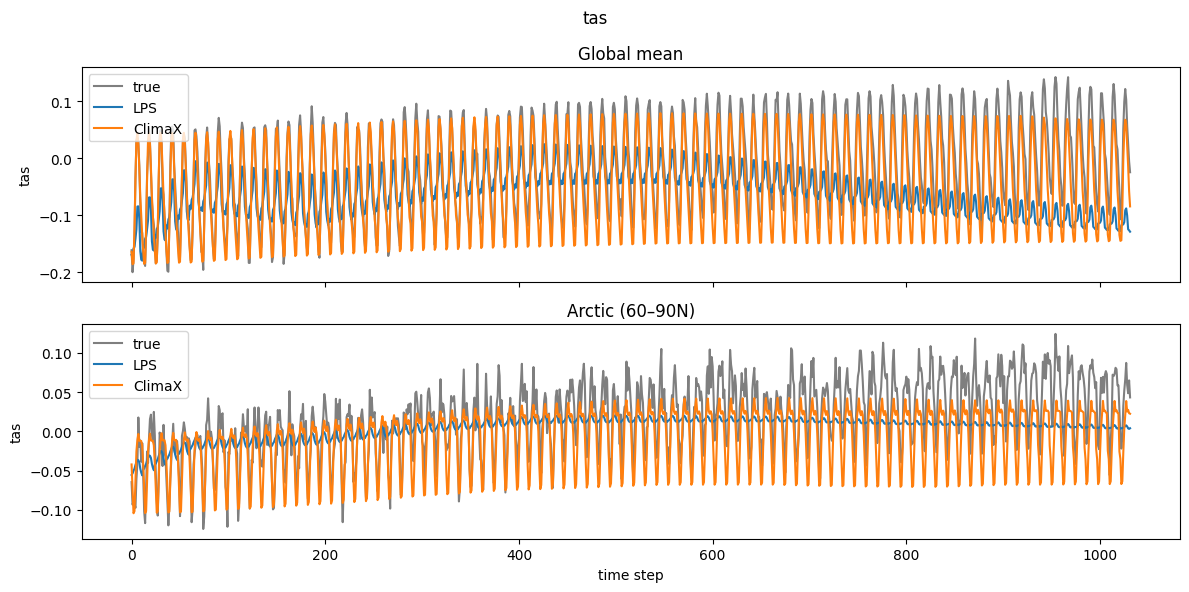

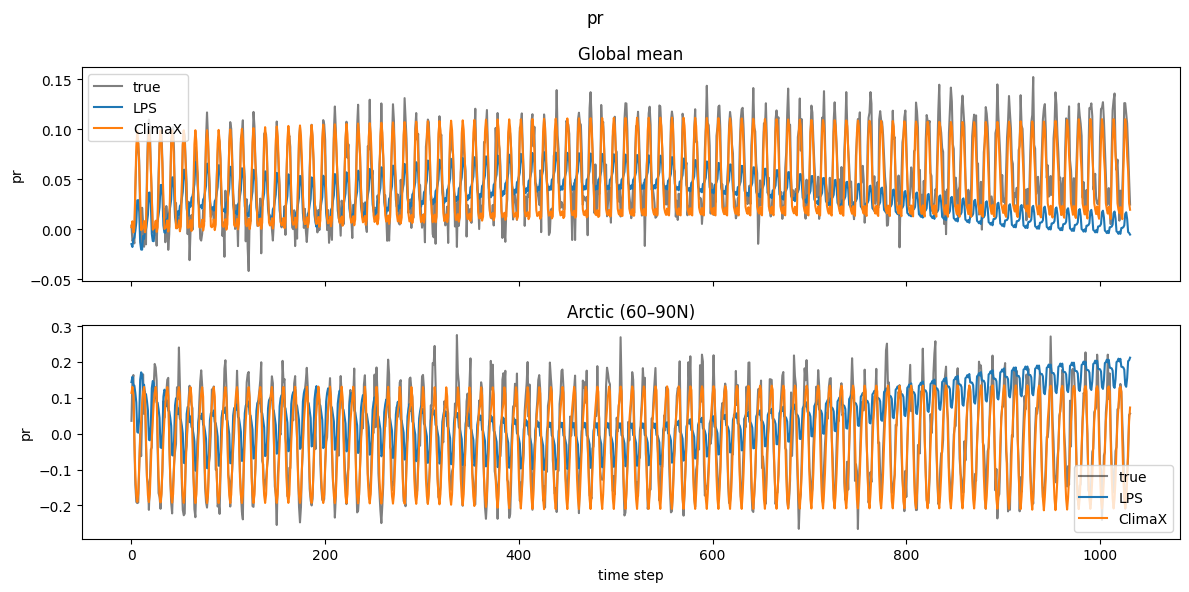

In [20]:
var_order = ["tas", "pr"]

# Lat weights
n_lat = Y_test.shape[-1]
lats = np.linspace(-90, 90, n_lat)
w = np.cos(np.deg2rad(lats)); w /= w.mean()

def global_mean(arr):
    return (arr * w[None, None, :]).mean(axis=(-1, -2))

def regional_mean(arr, lat_min, lat_max):
    idx = (lats >= lat_min) & (lats <= lat_max)
    w_r = w[idx]; w_r = w_r / w_r.mean()
    return (arr[:, :, idx] * w_r[None, None, :]).mean(axis=(-1, -2))

time = np.arange(n_test)
for i, var in enumerate(var_order):
    y_true    = results[var]["Y_local_test"]  # (n_time, lon, lat)
    models = {
        "LPS":    results[var]["preds_local"],  # (n_time, lon, lat)
        "ClimaX": preds_climax[:, i, :, :],     # (n_time, lon, lat)
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(var)

    for ax, label, rfn in zip(axes,
        ["Global mean", "Arctic (60–90N)"],
        [global_mean,   lambda a: regional_mean(a, 60, 90)],
    ):
        ax.plot(time, rfn(y_true), color="black", alpha=0.5, label="true")
        for mname, preds in models.items():
            ax.plot(time, rfn(preds), label=mname)
        ax.set_ylabel(var); ax.set_title(label); ax.legend()

    axes[-1].set_xlabel("time step")
    plt.tight_layout(); plt.show()

## Load EM-MPI dataset
### Input: ClimateBench

In [5]:
from climatebench import load_climatebench_data
data_root = "/proj/heal_pangu/users/x_tagty/"
data_path = data_root + 'climatebench/' # climatebench data + '/'
len_historical = 165
scenarios_train = ['historical', 'ssp126','ssp370','ssp585'] # 1pctCO2, picontrol, hist-aer, hist-GHG, abrupt-4xCO2
scenarios_test = ['ssp245']

X_train, Y_train = load_climatebench_data(
  simus=scenarios_train, 
  len_historical=len_historical, 
  data_path=data_path,
  avg_over_ensemble=True)

X_test, Y_test = load_climatebench_data(
  simus=scenarios_test, 
  len_historical=len_historical, 
  data_path=data_path,
  avg_over_ensemble=True)

/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:250: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  output_xr = output_xr.drop(['quantile'])


FrozenMappingWarningOnValuesAccess({'time': 165, 'latitude': 96, 'longitude': 144}) historical


/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:245: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'member' ('member',) The recommendation is to set join explicitly for this case.
  output_xr = xr.open_mfdataset(output_paths)
/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:250: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  output_xr = output_xr.drop(['quantile'])


FrozenMappingWarningOnValuesAccess({'time': 251, 'latitude': 96, 'longitude': 144}) ssp126


/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:250: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  output_xr = output_xr.drop(['quantile'])


FrozenMappingWarningOnValuesAccess({'time': 251, 'latitude': 96, 'longitude': 144}) ssp370


/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:245: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'member' ('member',) The recommendation is to set join explicitly for this case.
  output_xr = xr.open_mfdataset(output_paths)
/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:250: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  output_xr = output_xr.drop(['quantile'])


FrozenMappingWarningOnValuesAccess({'time': 251, 'latitude': 96, 'longitude': 144}) ssp585
FrozenMappingWarningOnValuesAccess({'time': 251, 'latitude': 96, 'longitude': 144}) ssp245


/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/climatebench.py:250: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  output_xr = output_xr.drop(['quantile'])


In [6]:
X_train

[<xarray.Dataset> Size: 37MB
 Dimensions:    (time: 165, latitude: 96, longitude: 144)
 Coordinates:
   * time       (time) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
   * latitude   (latitude) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
   * longitude  (longitude) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
 Data variables:
     CO2        (time) float64 1kB ...
     SO2        (time, latitude, longitude) float64 18MB ...
     CH4        (time) float64 1kB ...
     BC         (time, latitude, longitude) float64 18MB ...
 Attributes:
     experiment_id:  historical,
 <xarray.Dataset> Size: 56MB
 Dimensions:    (time: 251, latitude: 96, longitude: 144)
 Coordinates:
   * time       (time) int64 2kB 1850 1851 1852 1853 1854 ... 2097 2098 2099 2100
   * latitude   (latitude) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
   * longitude  (longitude) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
 Data variables:
     CO2        (time) float64 2kB 0

### Output dataset

In [1]:
from tqdm import tqdm

data_path = data_root + 'em-mpi/data/raw/CMIP6/MPI-ESM1-2-LR/' # raw data downloaded from CMIPX
data_path_interim = data_root + 'em-mpi/data/interim/CMIP6/MPI-ESM1-2-LR/' # interim data, such as, statistical summaries

scenarios_train = ['historical', 'ssp126','ssp370','ssp585'] # 1pctCO2, picontrol, hist-aer, hist-GHG, abrupt-4xCO2
scenarios_test = ['ssp245']

from mpi_esm1_2_lr import get_meta

slider = 10
data_var = 'pr'
meta = get_meta(data_path, data_path_interim)
len_historical = 165

In [17]:
print(meta.keys())
#print(meta.values())

dict_keys(['tas', 'pr', 'dtr', 'pr90', 'uas', 'vas', 'psl', 'huss'])


In [2]:
from mpi_esm1_2_lr import get_filepaths_mpi_esm1_2_lr
from mpi_esm1_2_lr import load_mpi_data_as_xr
# Get climatology:

scenarios = scenarios_train + scenarios_test + scenarios_aux
assert 'historical' in scenarios, 'historical scenario must be included in scenarios'

# Load precomputed ensemble summaries for runtime increase.
df = get_filepaths_mpi_esm1_2_lr(data_var=data_var,
        scenarios=scenarios,
        data_path=data_path_interim,
        filename_wildcard='ensemble.nc',
        frequency=meta[data_var]['frequency'],
        verbose=False)

datasets, climatology = load_mpi_data_as_xr(df=df, meta=meta, 
                climatology=None, m_member_subset=None,
                open_data_parallel=True)

  project_id       model_id realization_id    scenario data_var  \
0      CMIP6  MPI-ESM1-2-LR   r1-r50i1p1f1  historical       pr   
1      CMIP6  MPI-ESM1-2-LR   r1-r50i1p1f1      ssp126       pr   
2      CMIP6  MPI-ESM1-2-LR   r1-r50i1p1f1      ssp370       pr   
3      CMIP6  MPI-ESM1-2-LR   r1-r50i1p1f1      ssp585       pr   
4      CMIP6  MPI-ESM1-2-LR   r1-r50i1p1f1      ssp245       pr   

  nominal_resolution frequency       year  filename  \
0             250_km       mon  1850-2014  ensemble   
1             250_km       mon  2015-2100  ensemble   
2             250_km       mon  2015-2100  ensemble   
3             250_km       mon  2015-2100  ensemble   
4             250_km       mon  2015-2100  ensemble   

                                            filepath  
0  /proj/heal_pangu/users/x_tagty/em-mpi/data/int...  
1  /proj/heal_pangu/users/x_tagty/em-mpi/data/int...  
2  /proj/heal_pangu/users/x_tagty/em-mpi/data/int...  
3  /proj/heal_pangu/users/x_tagty/em-mpi/data/

/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoin

[########################################] | 100% Completed | 28.67 s


In [18]:
datasets[0]

<xarray.Dataset> Size: 1GB
Dimensions:    (member: 50, time: 165, latitude: 96, longitude: 192)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1850-12-31 1851-12-31 ... 2014-12-31
  * latitude   (latitude) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * longitude  (longitude) float64 2kB 0.0 1.875 3.75 ... 354.4 356.2 358.1
Dimensions without coordinates: member
Data variables:
    pr         (member, time, latitude, longitude) float64 1GB 0.02472 ... 0....
Attributes: (12/49)
    Conventions:                     CF-1.7 CMIP-6.2
    activity_id:                     CMIP
    branch_method:                   standard
    branch_time_in_child:            0.0
    branch_time_in_parent:           0.0
    contact:                         cmip6-mpi-esm@dkrz.de
    ...                              ...
    variant_label:                   r1i1p1f1
    license:                         CMIP6 model data produced by MPI-M is li...
    cmor_version:                    3.5.0
    tracking_id:                     hdl:21.14100/63a418ca-fb43-418a-affc-a60...
    DODS_EXTRA.Unlimited_Dimension:  time
    realization:                     r1i1p1f1-r50i1p1f1